# OCR vs No-OCR Analysis

This notebook provides a focused analysis comparing the performance of OCR-enabled vs non-OCR configurations in the MMLLM benchmarking framework.

## Overview

We will specifically analyze:
1. **Performance Comparison**: Direct comparison between OCR and no-OCR configurations
2. **Text Recognition Impact**: How OCR affects different types of visual tasks
3. **Efficiency Analysis**: Speed vs accuracy trade-offs with OCR processing
4. **Dataset-Specific Effects**: Which datasets benefit most from OCR capabilities
5. **Visual Understanding**: Analysis of how text extraction affects visual reasoning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Load data from OCR vs no-OCR experiments
RESULTS_PATH = Path("../results/ocr-vs-no-ocr")
print(f"OCR vs No-OCR analysis path: {RESULTS_PATH.absolute()}")
print(f"Path exists: {RESULTS_PATH.exists()}")

# Load OCR and no-OCR data
ocr_csv = RESULTS_PATH / "ocr" / "benchmark_results_20250720_155843.csv"
no_ocr_csv = RESULTS_PATH / "no-ocr" / "benchmark_results_20250720_161713.csv"

ocr_json = RESULTS_PATH / "ocr" / "benchmark_report_20250720_155843.json"
no_ocr_json = RESULTS_PATH / "no-ocr" / "benchmark_report_20250720_161713.json"

# Check file existence
print(f"OCR CSV exists: {ocr_csv.exists()}")
print(f"No-OCR CSV exists: {no_ocr_csv.exists()}")
print(f"OCR JSON exists: {ocr_json.exists()}")
print(f"No-OCR JSON exists: {no_ocr_json.exists()}")

# Load the data
ocr_data = pd.read_csv(ocr_csv) if ocr_csv.exists() else pd.DataFrame()
no_ocr_data = pd.read_csv(no_ocr_csv) if no_ocr_csv.exists() else pd.DataFrame()

ocr_data['config'] = 'ocr'
no_ocr_data['config'] = 'no-ocr'

combined_ocr_data = pd.concat([ocr_data, no_ocr_data], ignore_index=True)

print(f"OCR data shape: {ocr_data.shape}")
print(f"No-OCR data shape: {no_ocr_data.shape}")
print(f"Combined data shape: {combined_ocr_data.shape}")

OCR vs No-OCR analysis path: /home/kiko/mmllm/vis/../results/ocr-vs-no-ocr
Path exists: True
OCR CSV exists: True
No-OCR CSV exists: True
OCR JSON exists: True
No-OCR JSON exists: True
OCR data shape: (169, 39)
No-OCR data shape: (168, 39)
Combined data shape: (337, 39)


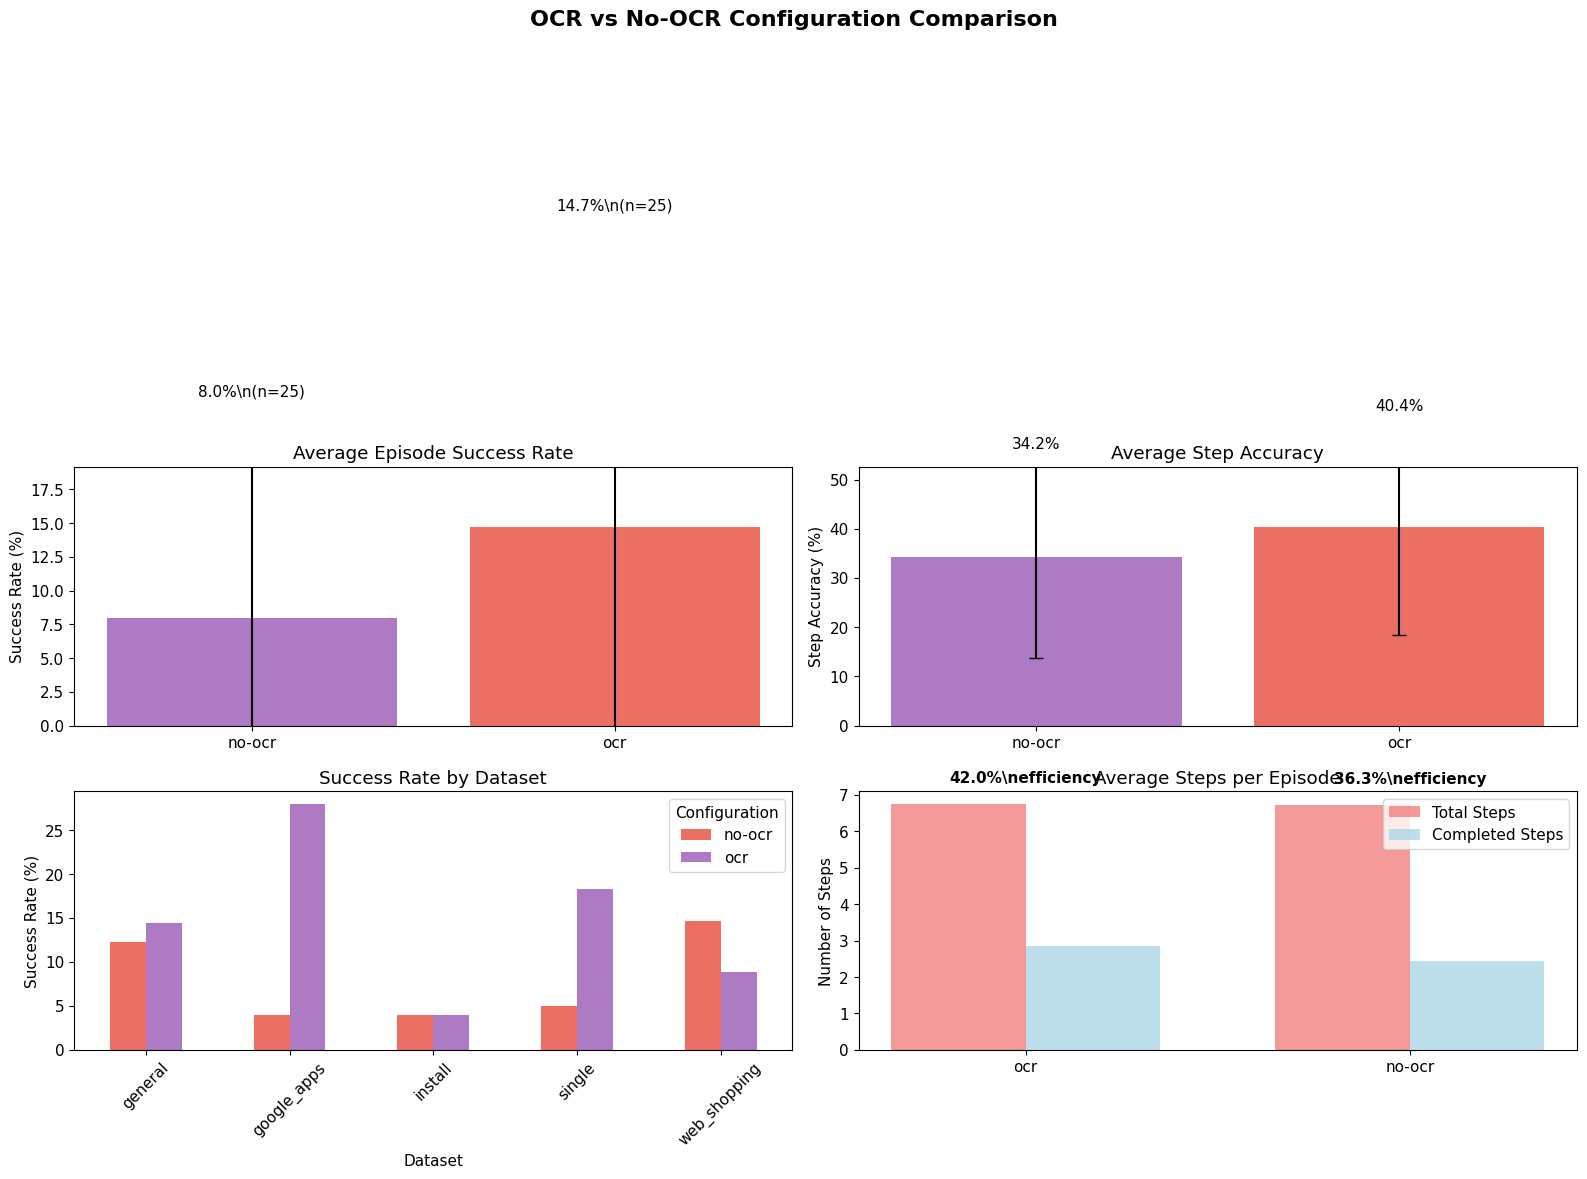

\n============================================================
OCR VS NO-OCR DETAILED COMPARISON
\nOCR Configuration:
  Episodes analyzed: 25
  Average success rate: 14.73% (±21.28)
  Average step accuracy: 40.41% (±22.02)
  Average total steps: 6.8 (±3.2)
  Average completed steps: 2.8 (±1.8)
  Dataset performance:
    install: 4.0% (n=5)
    general: 14.4% (n=5)
    web_shopping: 8.9% (n=5)
    google_apps: 28.0% (n=5)
    single: 18.3% (n=5)
\nNO-OCR Configuration:
  Episodes analyzed: 25
  Average success rate: 7.97% (±14.22)
  Average step accuracy: 34.23% (±20.45)
  Average total steps: 6.7 (±3.2)
  Average completed steps: 2.4 (±1.7)
  Dataset performance:
    install: 4.0% (n=5)
    general: 12.2% (n=5)
    web_shopping: 14.6% (n=5)
    google_apps: 4.0% (n=5)
    single: 5.0% (n=5)


In [2]:
# Create comprehensive OCR vs no-OCR comparison
if not combined_ocr_data.empty:
    
    # Calculate episode-level metrics
    episode_metrics = combined_ocr_data.groupby(['config', 'episode_id']).agg({
        'episode_success_rate': 'first',
        'episode_step_accuracy': 'first',
        'episode_total_steps': 'first',
        'episode_steps_completed': 'first',
        'dataset_name': 'first'
    }).reset_index()
    
    # Create comparison visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('OCR vs No-OCR Configuration Comparison', fontsize=16, fontweight='bold')
    
    # 1. Success Rate Comparison
    ax1 = axes[0, 0]
    success_comparison = episode_metrics.groupby('config')['episode_success_rate'].agg(['mean', 'std', 'count'])
    
    bars = ax1.bar(success_comparison.index, success_comparison['mean'], 
                   yerr=success_comparison['std'], capsize=5,
                   color=['#9B59B6', '#E74C3C'], alpha=0.8)
    ax1.set_title('Average Episode Success Rate')
    ax1.set_ylabel('Success Rate (%)')
    ax1.set_ylim(0, max(success_comparison['mean']) * 1.3)
    
    # Add value labels and sample sizes
    for i, (bar, count) in enumerate(zip(bars, success_comparison['count'])):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + success_comparison['std'].iloc[i] + 2,
                f'{height:.1f}%\\n(n={count})', ha='center', va='bottom')
    
    # 2. Step Accuracy Comparison  
    ax2 = axes[0, 1]
    accuracy_comparison = episode_metrics.groupby('config')['episode_step_accuracy'].agg(['mean', 'std'])
    
    bars = ax2.bar(accuracy_comparison.index, accuracy_comparison['mean'],
                   yerr=accuracy_comparison['std'], capsize=5,
                   color=['#9B59B6', '#E74C3C'], alpha=0.8)
    ax2.set_title('Average Step Accuracy')
    ax2.set_ylabel('Step Accuracy (%)')
    ax2.set_ylim(0, max(accuracy_comparison['mean']) * 1.3)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + accuracy_comparison['std'].iloc[i] + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 3. Performance by Dataset
    ax3 = axes[1, 0]
    dataset_performance = episode_metrics.groupby(['dataset_name', 'config'])['episode_success_rate'].mean().unstack(fill_value=0)
    
    dataset_performance.plot(kind='bar', ax=ax3, color=['#E74C3C', '#9B59B6'], alpha=0.8)
    ax3.set_title('Success Rate by Dataset')
    ax3.set_ylabel('Success Rate (%)')
    ax3.set_xlabel('Dataset')
    ax3.legend(title='Configuration')
    ax3.tick_params(axis='x', rotation=45)
    
    # 4. Efficiency Analysis (Steps)
    ax4 = axes[1, 1]
    
    # Calculate efficiency metrics
    efficiency_data = []
    for config in ['ocr', 'no-ocr']:
        config_data = episode_metrics[episode_metrics['config'] == config]
        avg_total_steps = config_data['episode_total_steps'].mean()
        avg_completed_steps = config_data['episode_steps_completed'].mean()
        completion_rate = (avg_completed_steps / avg_total_steps) * 100 if avg_total_steps > 0 else 0
        
        efficiency_data.append({
            'config': config,
            'avg_total_steps': avg_total_steps,
            'avg_completed_steps': avg_completed_steps,
            'completion_rate': completion_rate
        })
    
    efficiency_df = pd.DataFrame(efficiency_data)
    
    x_pos = np.arange(len(efficiency_df))
    width = 0.35
    
    bars1 = ax4.bar(x_pos - width/2, efficiency_df['avg_total_steps'], width,
                   label='Total Steps', alpha=0.8, color='lightcoral')
    bars2 = ax4.bar(x_pos + width/2, efficiency_df['avg_completed_steps'], width,
                   label='Completed Steps', alpha=0.8, color='lightblue')
    
    ax4.set_title('Average Steps per Episode')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(efficiency_df['config'])
    ax4.set_ylabel('Number of Steps')
    ax4.legend()
    
    # Add efficiency percentages
    for i, (total, completed) in enumerate(zip(efficiency_df['avg_total_steps'], efficiency_df['avg_completed_steps'])):
        efficiency = (completed / total) * 100 if total > 0 else 0
        ax4.text(i, max(total, completed) + 0.5, f'{efficiency:.1f}%\\nefficiency', 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\\n" + "="*60)
    print("OCR VS NO-OCR DETAILED COMPARISON")
    print("="*60)
    
    for config in ['ocr', 'no-ocr']:
        config_data = episode_metrics[episode_metrics['config'] == config]
        print(f"\\n{config.upper()} Configuration:")
        print(f"  Episodes analyzed: {len(config_data)}")
        print(f"  Average success rate: {config_data['episode_success_rate'].mean():.2f}% (±{config_data['episode_success_rate'].std():.2f})")
        print(f"  Average step accuracy: {config_data['episode_step_accuracy'].mean():.2f}% (±{config_data['episode_step_accuracy'].std():.2f})")
        print(f"  Average total steps: {config_data['episode_total_steps'].mean():.1f} (±{config_data['episode_total_steps'].std():.1f})")
        print(f"  Average completed steps: {config_data['episode_steps_completed'].mean():.1f} (±{config_data['episode_steps_completed'].std():.1f})")
        
        # Dataset breakdown
        print(f"  Dataset performance:")
        for dataset in config_data['dataset_name'].unique():
            dataset_perf = config_data[config_data['dataset_name'] == dataset]['episode_success_rate'].mean()
            dataset_count = len(config_data[config_data['dataset_name'] == dataset])
            print(f"    {dataset}: {dataset_perf:.1f}% (n={dataset_count})")

else:
    print("No OCR vs no-OCR data available!")

## OCR Impact Analysis

Let's analyze how OCR capabilities affect performance across different action types and visual understanding tasks.

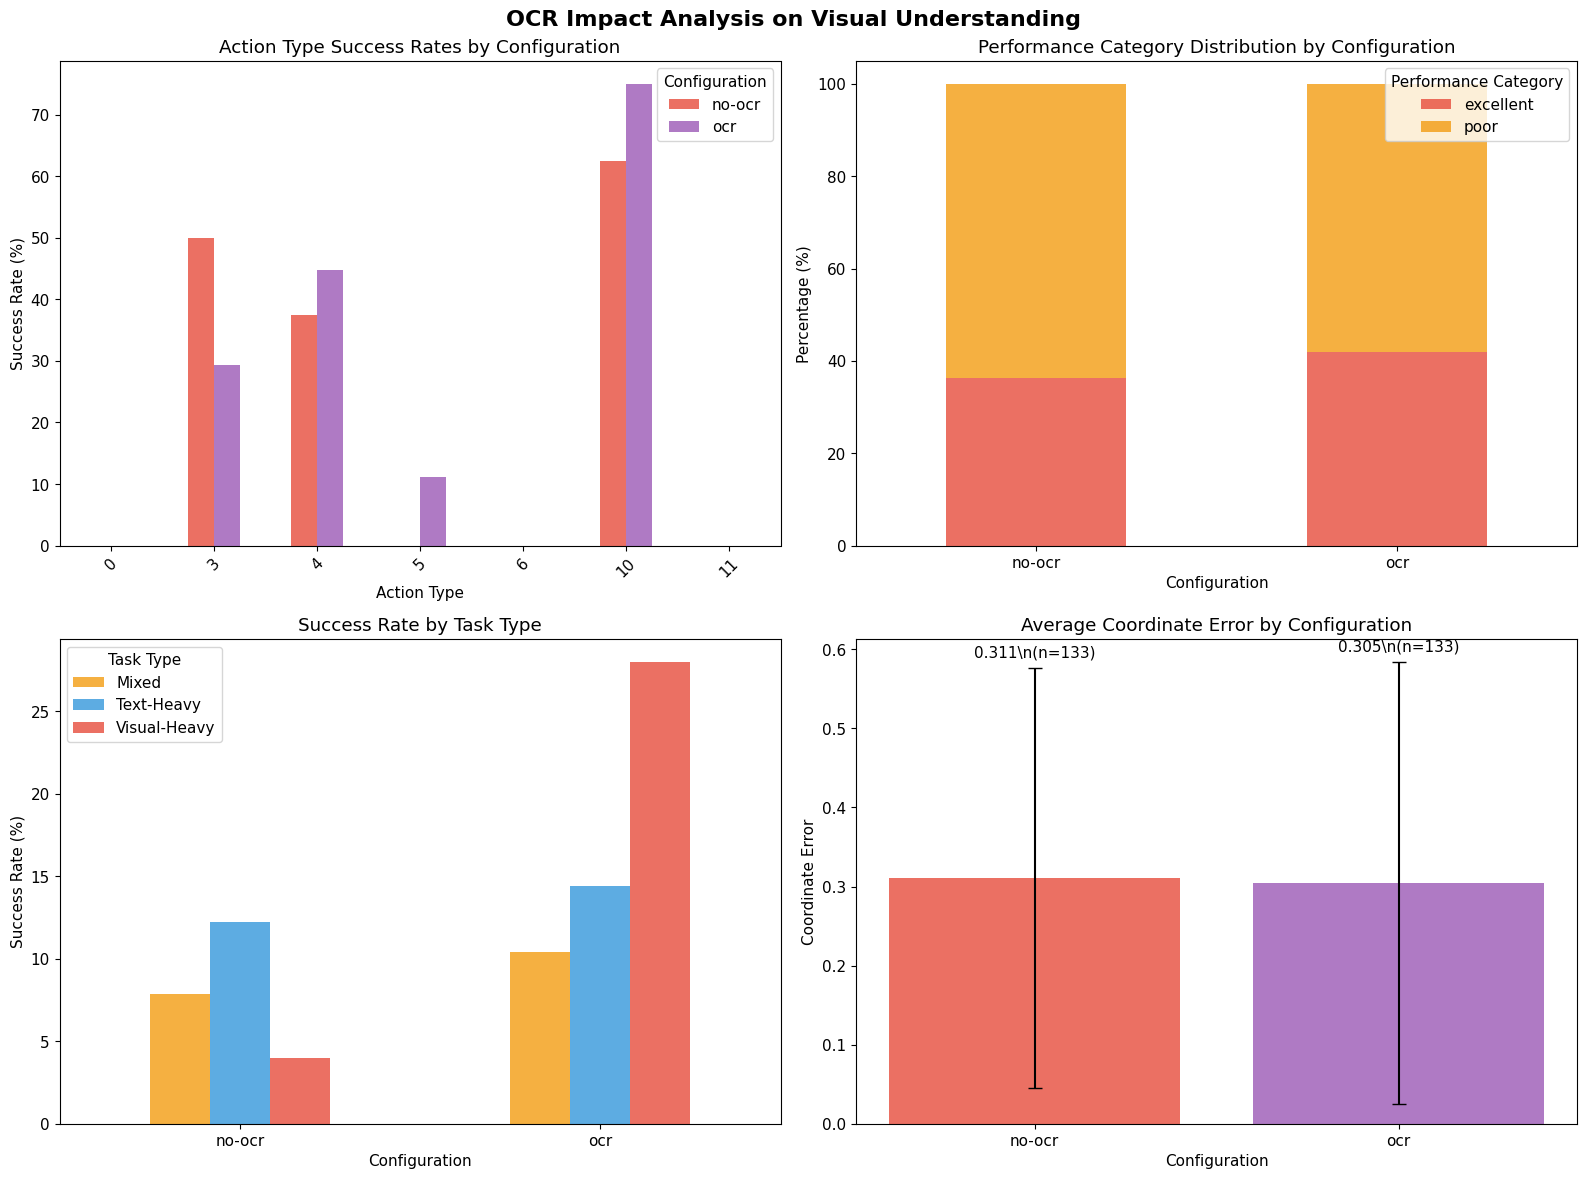

\n======================================================================
OCR IMPACT INSIGHTS
\nAction Type Performance Differences:
  0: OCR nan% vs No-OCR 0.0% (diff: +nan%)
  3: OCR 29.4% vs No-OCR 50.0% (diff: -20.6%)
  4: OCR 44.7% vs No-OCR 37.4% (diff: +7.3%)
  5: OCR 11.1% vs No-OCR 0.0% (diff: +11.1%)
  6: OCR 0.0% vs No-OCR 0.0% (diff: +0.0%)
  10: OCR 75.0% vs No-OCR 62.5% (diff: +12.5%)
  11: OCR 0.0% vs No-OCR nan% (diff: +nan%)
\nTask Type Impact:
  Mixed: OCR 10.4% vs No-OCR 7.9% (diff: +2.5%)
  Text-Heavy: OCR 14.4% vs No-OCR 12.2% (diff: +2.2%)
  Visual-Heavy: OCR 28.0% vs No-OCR 4.0% (diff: +24.0%)
\nDataset-Specific OCR Benefits:
  general: ~ OCR 14.4% vs No-OCR 12.2% (diff: +2.2%)
  google_apps: ✓ OCR 28.0% vs No-OCR 4.0% (diff: +24.0%)
  install: ~ OCR 4.0% vs No-OCR 4.0% (diff: +0.0%)
  single: ✓ OCR 18.3% vs No-OCR 5.0% (diff: +13.3%)
  web_shopping: ✗ OCR 8.9% vs No-OCR 14.6% (diff: -5.7%)


In [3]:
# Analyze OCR impact on different action types and visual tasks
if not combined_ocr_data.empty:
    
    # Create OCR-specific analysis
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('OCR Impact Analysis on Visual Understanding', fontsize=16, fontweight='bold')
    
    # 1. Action Type Success Rates by Configuration
    ax1 = axes[0, 0]
    action_success = combined_ocr_data.groupby(['config', 'model_action_type']).agg({
        'step_action_match': ['count', 'sum']
    })
    action_success.columns = ['total', 'successful']
    action_success['success_rate'] = (action_success['successful'] / action_success['total']) * 100
    action_success = action_success.reset_index()
    
    action_pivot = action_success.pivot(index='model_action_type', columns='config', values='success_rate')
    action_pivot.plot(kind='bar', ax=ax1, color=['#E74C3C', '#9B59B6'], alpha=0.8)
    ax1.set_title('Action Type Success Rates by Configuration')
    ax1.set_ylabel('Success Rate (%)')
    ax1.set_xlabel('Action Type')
    ax1.legend(title='Configuration')
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Performance Category Distribution
    ax2 = axes[0, 1]
    perf_by_config = combined_ocr_data.groupby(['config', 'performance_category']).size().unstack(fill_value=0)
    perf_by_config_pct = perf_by_config.div(perf_by_config.sum(axis=1), axis=0) * 100
    
    perf_by_config_pct.plot(kind='bar', ax=ax2, stacked=True, 
                           color=['#E74C3C', '#F39C12', '#27AE60'], alpha=0.8)
    ax2.set_title('Performance Category Distribution by Configuration')
    ax2.set_ylabel('Percentage (%)')
    ax2.set_xlabel('Configuration')
    ax2.legend(title='Performance Category')
    ax2.tick_params(axis='x', rotation=0)
    
    # 3. Text-heavy vs Visual tasks analysis
    ax3 = axes[1, 0]
    
    # Define text-heavy vs visual task categories (you may need to adjust based on your datasets)
    text_heavy_datasets = ['general']  # Adjust based on your actual datasets
    visual_datasets = ['google_apps', 'webarena']  # Adjust based on your actual datasets
    
    # Categorize episodes
    def categorize_task_type(dataset_name):
        if dataset_name in text_heavy_datasets:
            return 'Text-Heavy'
        elif dataset_name in visual_datasets:
            return 'Visual-Heavy'
        else:
            return 'Mixed'
    
    combined_ocr_data['task_type'] = combined_ocr_data['dataset_name'].apply(categorize_task_type)
    
    task_type_perf = combined_ocr_data.groupby(['config', 'task_type', 'episode_id']).agg({
        'episode_success_rate': 'first'
    }).reset_index()
    
    task_success = task_type_perf.groupby(['config', 'task_type'])['episode_success_rate'].mean().unstack(fill_value=0)
    task_success.plot(kind='bar', ax=ax3, color=['#F39C12', '#3498DB', '#E74C3C'], alpha=0.8)
    ax3.set_title('Success Rate by Task Type')
    ax3.set_ylabel('Success Rate (%)')
    ax3.set_xlabel('Configuration')
    ax3.legend(title='Task Type')
    ax3.tick_params(axis='x', rotation=0)
    
    # 4. Coordinate Error Analysis (for visual localization tasks)
    ax4 = axes[1, 1]
    coord_data = combined_ocr_data[combined_ocr_data['coordinate_error'].notna()]
    if not coord_data.empty:
        coord_by_config = coord_data.groupby('config')['coordinate_error'].agg(['mean', 'std', 'count'])
        
        bars = ax4.bar(coord_by_config.index, coord_by_config['mean'],
                      yerr=coord_by_config['std'], capsize=5,
                      color=['#E74C3C', '#9B59B6'], alpha=0.8)
        ax4.set_title('Average Coordinate Error by Configuration')
        ax4.set_ylabel('Coordinate Error')
        ax4.set_xlabel('Configuration')
        
        # Add value labels
        for i, (bar, count) in enumerate(zip(bars, coord_by_config['count'])):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + coord_by_config['std'].iloc[i] + 0.01,
                    f'{height:.3f}\\n(n={count})', ha='center', va='bottom')
    else:
        ax4.text(0.5, 0.5, 'No coordinate data available', 
                ha='center', va='center', transform=ax4.transAxes)
    
    plt.tight_layout()
    plt.show()
    
    # Print OCR impact insights
    print("\\n" + "="*70)
    print("OCR IMPACT INSIGHTS")
    print("="*70)
    
    # Compare action type performance
    print("\\nAction Type Performance Differences:")
    for action_type in action_pivot.index:
        if 'ocr' in action_pivot.columns and 'no-ocr' in action_pivot.columns:
            ocr_perf = action_pivot.loc[action_type, 'ocr']
            no_ocr_perf = action_pivot.loc[action_type, 'no-ocr']
            diff = ocr_perf - no_ocr_perf
            print(f"  {action_type}: OCR {ocr_perf:.1f}% vs No-OCR {no_ocr_perf:.1f}% (diff: {diff:+.1f}%)")
    
    # Task type impact
    print("\\nTask Type Impact:")
    for task_type in task_success.columns:
        if 'ocr' in task_success.index and 'no-ocr' in task_success.index:
            ocr_perf = task_success.loc['ocr', task_type]
            no_ocr_perf = task_success.loc['no-ocr', task_type]
            diff = ocr_perf - no_ocr_perf
            print(f"  {task_type}: OCR {ocr_perf:.1f}% vs No-OCR {no_ocr_perf:.1f}% (diff: {diff:+.1f}%)")
    
    # Dataset-specific OCR benefits
    print("\\nDataset-Specific OCR Benefits:")
    dataset_comparison = episode_metrics.groupby(['dataset_name', 'config'])['episode_success_rate'].mean().unstack(fill_value=0)
    for dataset in dataset_comparison.index:
        if 'ocr' in dataset_comparison.columns and 'no-ocr' in dataset_comparison.columns:
            ocr_perf = dataset_comparison.loc[dataset, 'ocr']
            no_ocr_perf = dataset_comparison.loc[dataset, 'no-ocr']
            diff = ocr_perf - no_ocr_perf
            benefit = "✓" if diff > 5 else "~" if diff > -5 else "✗"
            print(f"  {dataset}: {benefit} OCR {ocr_perf:.1f}% vs No-OCR {no_ocr_perf:.1f}% (diff: {diff:+.1f}%)")

else:
    print("No data available for OCR impact analysis!")

## JSON Report Analysis

Let's load and analyze the structured JSON reports for additional insights.

Loaded JSON reports successfully!


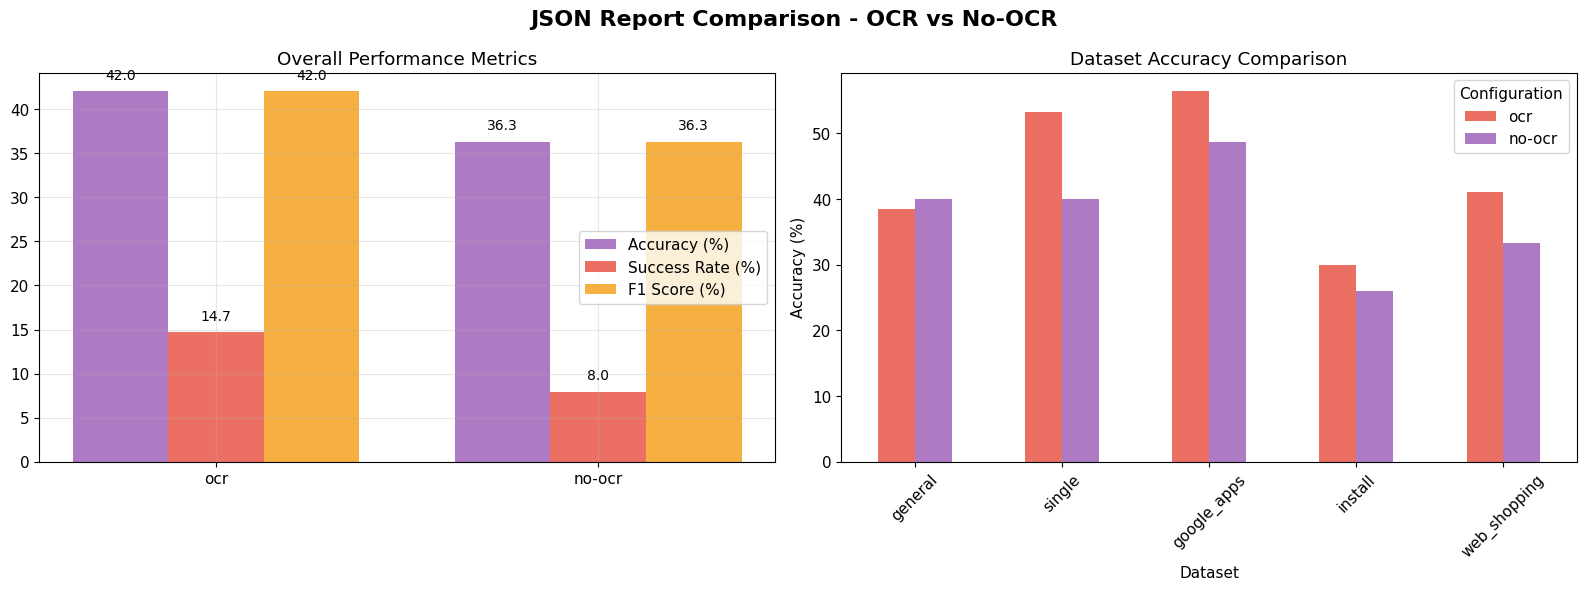

\n======================================================================
JSON REPORT DETAILED COMPARISON
\nOCR Configuration:
  Overall Accuracy: 42.01%
  Success Rate: 14.73%
  F1 Score: 0.420
  Precision: 0.420
  Recall: 0.420
  Total Episodes: 25
  Total Steps: 169
  Dataset Performance:
    general: 38.5% accuracy
    google_apps: 56.4% accuracy
    install: 30.0% accuracy
    single: 53.3% accuracy
    web_shopping: 41.0% accuracy
\nNO-OCR Configuration:
  Overall Accuracy: 36.31%
  Success Rate: 7.97%
  F1 Score: 0.363
  Precision: 0.363
  Recall: 0.363
  Total Episodes: 25
  Total Steps: 168
  Dataset Performance:
    general: 40.0% accuracy
    google_apps: 48.7% accuracy
    install: 26.0% accuracy
    single: 40.0% accuracy
    web_shopping: 33.3% accuracy
\n======================================================================
OCR PERFORMANCE INSIGHTS
\nOverall OCR Impact:
  Accuracy improvement: +5.70% (42.01% vs 36.31%)
  Success rate improvement: +6.77% (14.73% vs 7.97%)


In [4]:
# Load and analyze JSON reports
def load_json_report(file_path):
    """Load JSON report file safely"""
    try:
        with open(file_path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Load both reports
ocr_report = load_json_report(ocr_json) if ocr_json.exists() else None
no_ocr_report = load_json_report(no_ocr_json) if no_ocr_json.exists() else None

if ocr_report and no_ocr_report:
    print("Loaded JSON reports successfully!")
    
    # Create JSON report comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('JSON Report Comparison - OCR vs No-OCR', fontsize=16, fontweight='bold')
    
    # 1. Overall metrics comparison
    ax1 = axes[0]
    
    if 'overall_metrics' in ocr_report and 'overall_metrics' in no_ocr_report:
        metrics_data = {
            'ocr': ocr_report['overall_metrics'],
            'no-ocr': no_ocr_report['overall_metrics']
        }
        
        configs = list(metrics_data.keys())
        accuracy = [metrics_data[config]['accuracy'] * 100 for config in configs]
        success_rate = [metrics_data[config]['success_rate'] for config in configs]
        f1_score = [metrics_data[config]['f1_score'] * 100 for config in configs]
        
        x_pos = np.arange(len(configs))
        width = 0.25
        
        bars1 = ax1.bar(x_pos - width, accuracy, width, label='Accuracy (%)', alpha=0.8, color='#9B59B6')
        bars2 = ax1.bar(x_pos, success_rate, width, label='Success Rate (%)', alpha=0.8, color='#E74C3C')
        bars3 = ax1.bar(x_pos + width, f1_score, width, label='F1 Score (%)', alpha=0.8, color='#F39C12')
        
        ax1.set_title('Overall Performance Metrics')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(configs)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Add value labels
        for bars in [bars1, bars2, bars3]:
            for bar in bars:
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                        f'{height:.1f}', ha='center', va='bottom', fontsize=10)
    
    # 2. Dataset-specific performance
    ax2 = axes[1]
    
    if 'dataset_metrics' in ocr_report and 'dataset_metrics' in no_ocr_report:
        dataset_comparison = {}
        
        # Combine dataset metrics
        all_datasets = set(ocr_report['dataset_metrics'].keys()) | set(no_ocr_report['dataset_metrics'].keys())
        
        for dataset in all_datasets:
            dataset_comparison[dataset] = {
                'ocr': ocr_report['dataset_metrics'].get(dataset, {}).get('accuracy', 0) * 100,
                'no-ocr': no_ocr_report['dataset_metrics'].get(dataset, {}).get('accuracy', 0) * 100
            }
        
        dataset_df = pd.DataFrame(dataset_comparison).T
        dataset_df.plot(kind='bar', ax=ax2, color=['#E74C3C', '#9B59B6'], alpha=0.8)
        ax2.set_title('Dataset Accuracy Comparison')
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_xlabel('Dataset')
        ax2.legend(title='Configuration')
        ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed report comparison
    print("\\n" + "="*70)
    print("JSON REPORT DETAILED COMPARISON")
    print("="*70)
    
    for config_name, report in [('OCR', ocr_report), ('NO-OCR', no_ocr_report)]:
        print(f"\\n{config_name} Configuration:")
        
        if 'overall_metrics' in report:
            metrics = report['overall_metrics']
            print(f"  Overall Accuracy: {metrics.get('accuracy', 0)*100:.2f}%")
            print(f"  Success Rate: {metrics.get('success_rate', 0):.2f}%")
            print(f"  F1 Score: {metrics.get('f1_score', 0):.3f}")
            print(f"  Precision: {metrics.get('precision', 0):.3f}")
            print(f"  Recall: {metrics.get('recall', 0):.3f}")
            print(f"  Total Episodes: {metrics.get('total_episodes', 0)}")
            print(f"  Total Steps: {metrics.get('total_steps', 0)}")
        
        if 'dataset_metrics' in report:
            print(f"  Dataset Performance:")
            for dataset, dataset_metrics in report['dataset_metrics'].items():
                print(f"    {dataset}: {dataset_metrics.get('accuracy', 0)*100:.1f}% accuracy")
    
    # Print OCR-specific insights
    print("\\n" + "="*70)
    print("OCR PERFORMANCE INSIGHTS")
    print("="*70)
    
    if 'overall_metrics' in ocr_report and 'overall_metrics' in no_ocr_report:
        ocr_acc = ocr_report['overall_metrics']['accuracy'] * 100
        no_ocr_acc = no_ocr_report['overall_metrics']['accuracy'] * 100
        acc_diff = ocr_acc - no_ocr_acc
        
        ocr_success = ocr_report['overall_metrics']['success_rate']
        no_ocr_success = no_ocr_report['overall_metrics']['success_rate']
        success_diff = ocr_success - no_ocr_success
        
        print(f"\\nOverall OCR Impact:")
        print(f"  Accuracy improvement: {acc_diff:+.2f}% ({ocr_acc:.2f}% vs {no_ocr_acc:.2f}%)")
        print(f"  Success rate improvement: {success_diff:+.2f}% ({ocr_success:.2f}% vs {no_ocr_success:.2f}%)")
        
        if acc_diff > 2:
            print(f"  → OCR provides significant accuracy improvement")
        elif acc_diff > -2:
            print(f"  → OCR has minimal impact on accuracy")
        else:
            print(f"  → OCR may be hindering performance")

else:
    print("Could not load JSON reports for comparison.")